In [47]:
import cv2
import matplotlib.pyplot as plt
from skimage.morphology import dilation, erosion, opening, closing
from skimage.morphology import footprint_rectangle
import numpy as np
from scipy.ndimage import morphological_gradient


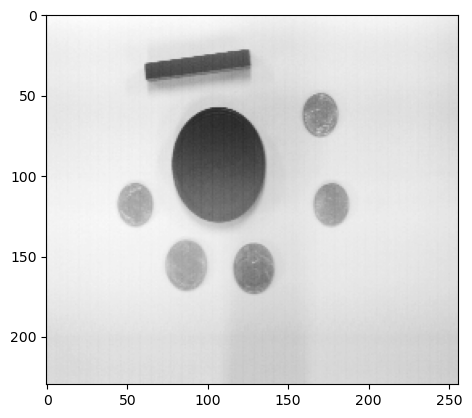

In [2]:
morpho = cv2.imread("images/MORPHO.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(morpho, cmap="gray")
plt.show()

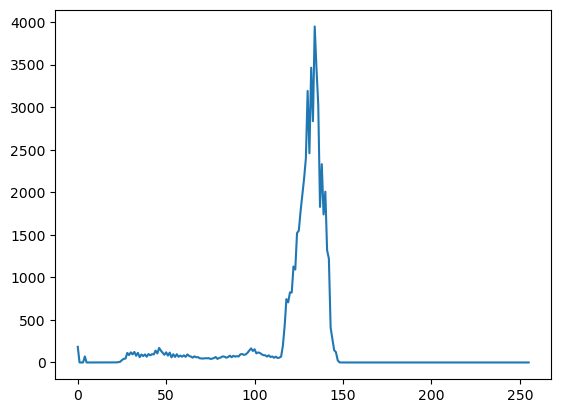

In [3]:
hist = cv2.calcHist([morpho], [0], None, [256], [0, 256])
plt.plot(hist)

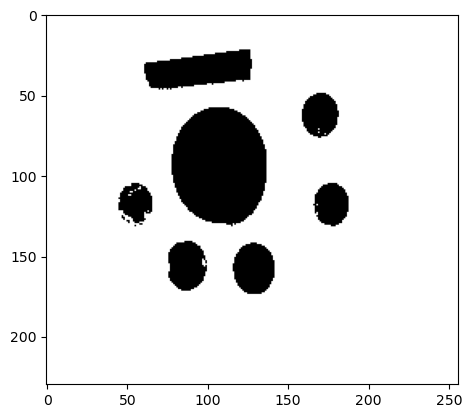

In [15]:

thres_value, thres_image = cv2.threshold(morpho, 110, 115, cv2.THRESH_BINARY)

plt.imshow(thres_image, cmap="gray")
plt.show()

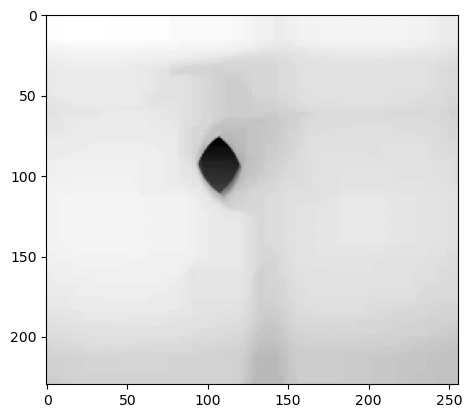

In [19]:
dilated_morpho = dilation(morpho, footprint=footprint_rectangle((29,29)))

plt.imshow(dilated_morpho, cmap="gray")
plt.show()


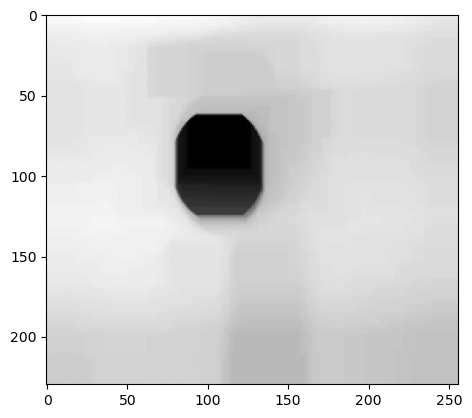

In [22]:
eroded_morpho_dilated = erosion(dilated_morpho, footprint=footprint_rectangle((29,29)))
plt.imshow(eroded_morpho_dilated, cmap="gray")
plt.show()

In [ ]:

n = 11
kernel = np.empty((n, n), dtype=object) 
kernel[:] = None

c = n // 2
kernel[c, :] = 1
kernel[:, c] = 1

print(kernel)

[[None None None None None 1 None None None None None]
 [None None None None None 1 None None None None None]
 [None None None None None 1 None None None None None]
 [None None None None None 1 None None None None None]
 [None None None None None 1 None None None None None]
 [1 1 1 1 1 1 1 1 1 1 1]
 [None None None None None 1 None None None None None]
 [None None None None None 1 None None None None None]
 [None None None None None 1 None None None None None]
 [None None None None None 1 None None None None None]
 [None None None None None 1 None None None None None]]


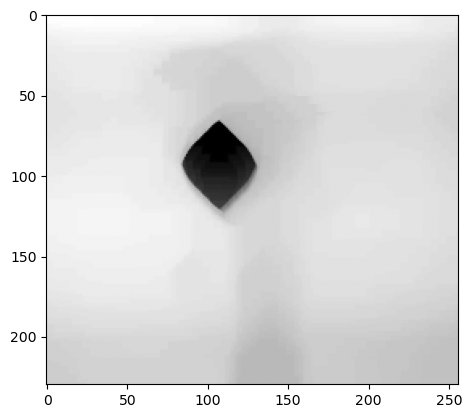

In [38]:
eroded_morpho_dilated2 = erosion(eroded_morpho_dilated, footprint=kernel)
plt.imshow(eroded_morpho_dilated2, cmap="gray")
plt.show()

In [40]:
print(np.max(eroded_morpho_dilated2))
print(np.max(thres_image))

148
115


### Sobre la original

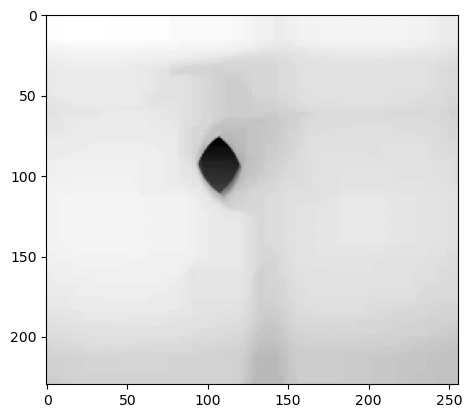

In [42]:
morpho_dilatado = dilation(morpho, footprint=footprint_rectangle((29,29)))
plt.imshow(morpho_dilatado, cmap="gray")
plt.show()

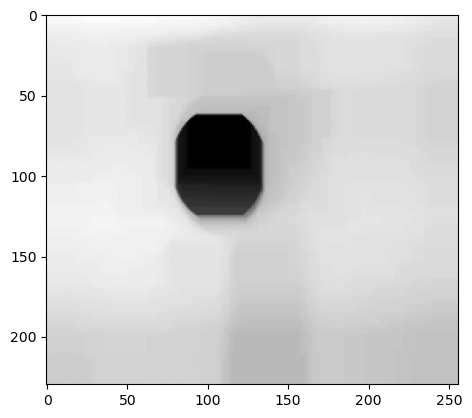

In [43]:
morphodilatado_erodado = erosion(morpho_dilatado, footprint=footprint_rectangle((29,29)))
plt.imshow(morphodilatado_erodado, cmap="gray")
plt.show()

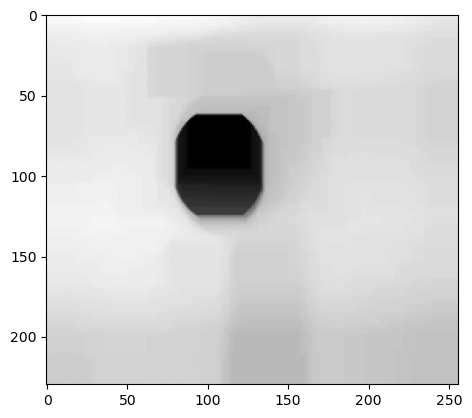

In [44]:
eroded_morpho_dilated2 = erosion(morphodilatado_erodado, footprint=kernel)
plt.imshow(morphodilatado_erodado, cmap="gray")
plt.show()

In [45]:
print(np.max(eroded_morpho_dilated2))

146


# Gradiente morfológico

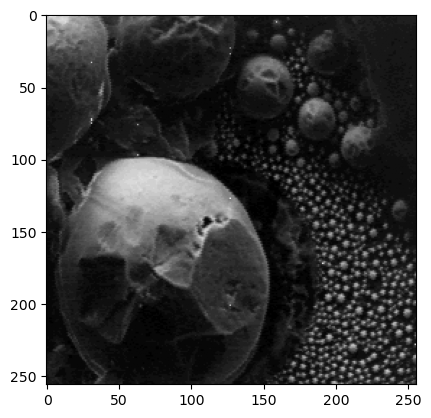

In [46]:
meb = cv2.imread("images/MEB.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(meb, cmap="gray")
plt.show()

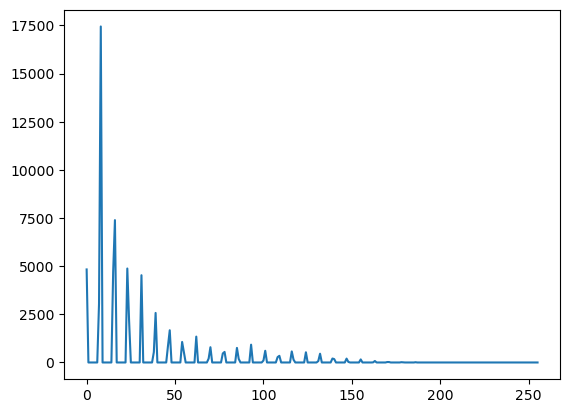

In [56]:
mgimage = morphological_gradient(meb, size=((3,3)))
hist1 = cv2.calcHist([mgimage], [0], None, [256], [0, 256])
plt.plot(hist1)

from skimage import exposure


rescaled_img = exposure.rescale_intensity(mgimage, in_range=(0,100), out_range=(0,255))



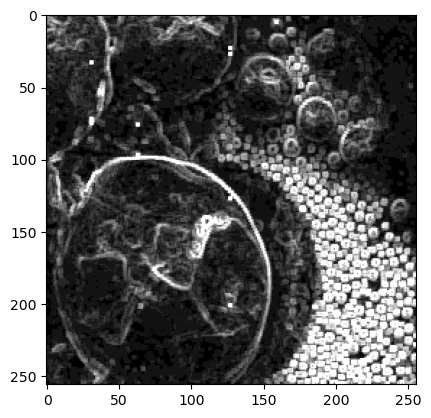

In [57]:

plt.imshow(rescaled_img, cmap="gray")
plt.show()

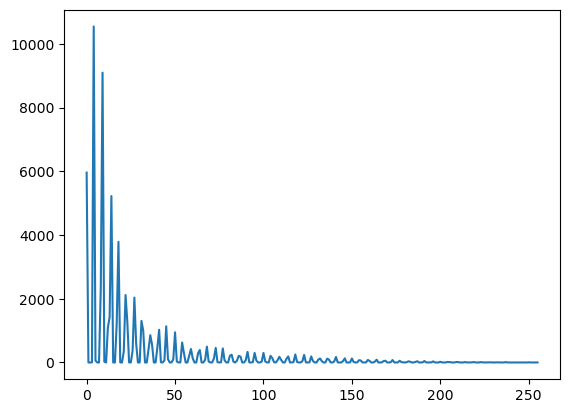

In [64]:

from skimage.filters import sobel_h, sobel_v, sobel

#Aplica el filtro Sobel horizontal
img_sh = sobel_h(meb)
#Aplica el filtro Sobel vertical
img_sv = sobel_v(meb)
#Calcula bordes usando el filtro de sobel
final = np.abs(img_sh) + np.abs(img_sv)
final = (final / np.max(final) * 255).astype(np.uint8)
hist2c = cv2.calcHist([final], [0], None, [256], [0, 256])
plt.plot(hist2c)

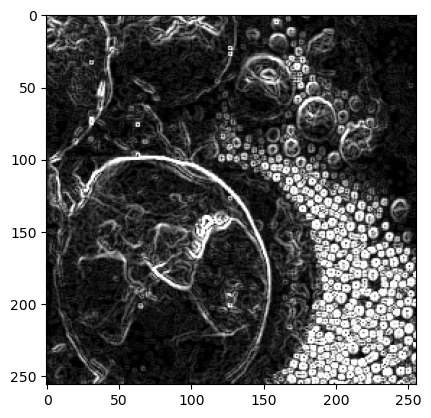

In [63]:
img_escalada = exposure.rescale_intensity(final, in_range=(0,100), out_range=(0,255))

plt.imshow(img_escalada, cmap="gray")
plt.show()

# Operadores de apertura y cierre

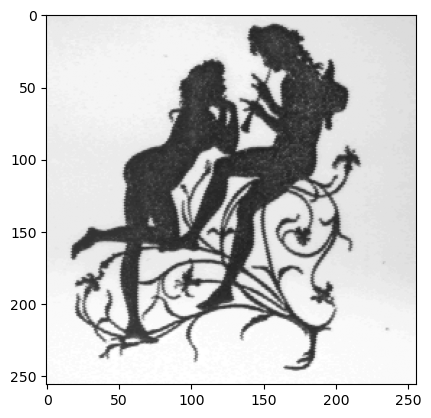

In [78]:
amour = cv2.imread("images/AMOUR.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(amour, cmap="gray")
plt.show()

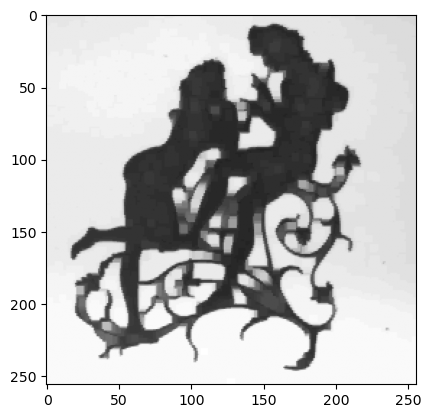

In [79]:
opening_image = opening(amour, footprint=footprint_rectangle((5,5)))
plt.imshow(opening_image, cmap="gray")
plt.show()

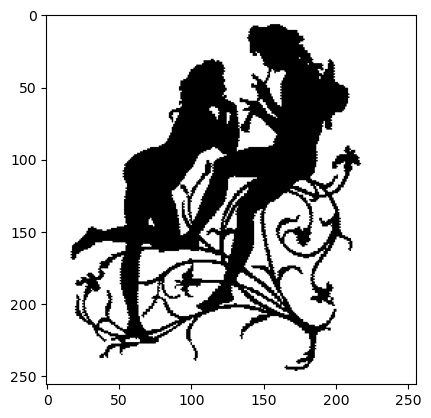

In [80]:
amour_umbralizada = cv2.threshold(amour, 30, 35, cv2.THRESH_BINARY)[1]
plt.imshow(amour_umbralizada, cmap="gray")
plt.show()


In [81]:
n = 3
kernelDiagIzq = np.empty((n,n), dtype=object)
kernelDiagIzq[:] = None

for i in range(n):
    for j in range(n):
        if i == j:
            kernelDiagIzq[i,j] = 1
print(kernelDiagIzq)

[[1 None None]
 [None 1 None]
 [None None 1]]


In [ ]:
n = 3
kernelDiagDer = np.empty((n,n), dtype=object)
kernelDiagDer[:] = None

offset = n-1
for i in range(n):
    for j in range(n):
        if i + j == offset:
            kernelDiagDer[i, j] = 1
print(kernelDiagDer)

[[None None 1]
 [None 1 None]
 [1 None None]]


In [85]:
kernelHor = np.ones((1,3), dtype = object)
print(kernelHor)

[[1 1 1]]


In [88]:
kernelVert = np.ones((3,1), dtype = object)
print(kernelVert)

[[1]
 [1]
 [1]]


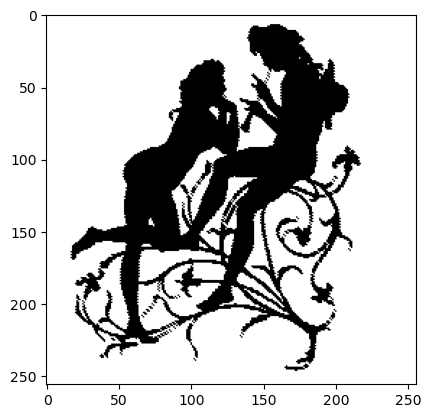

In [89]:
final = closing(amour_umbralizada, kernelDiagIzq)
plt.imshow(final, cmap="gray")
plt.show()

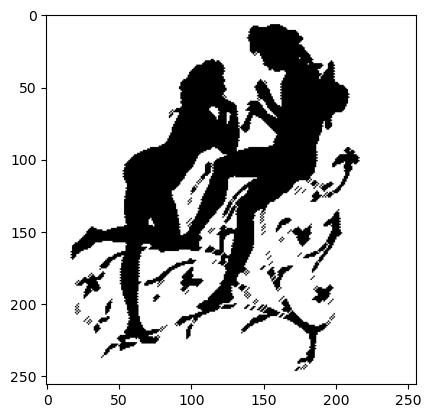

In [90]:
final = closing(final, kernelDiagDer)
plt.imshow(final, cmap="gray")
plt.show()

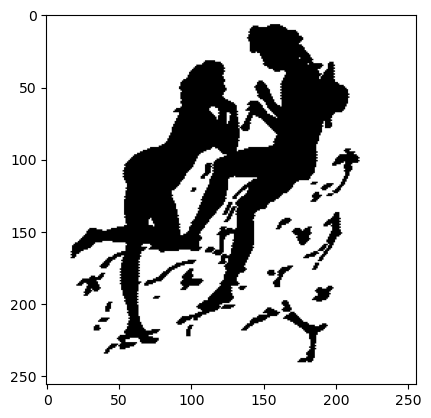

In [91]:
final = closing(final, kernelHor)
plt.imshow(final, cmap="gray")
plt.show()

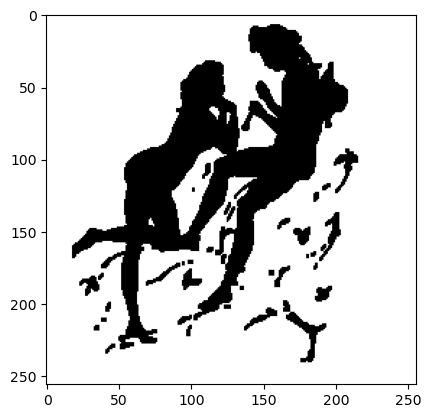

In [92]:
final = closing(final, kernelVert)
plt.imshow(final, cmap="gray")
plt.show()

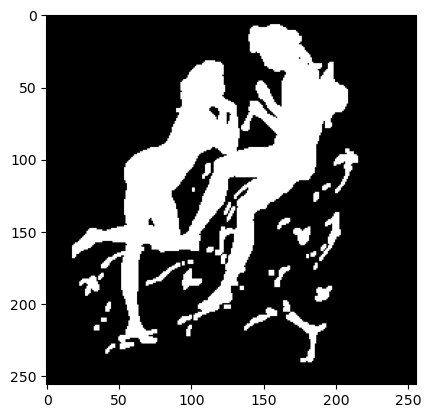

In [93]:
neg = cv2.bitwise_not(final)
plt.imshow(neg, cmap="gray")
plt.show()

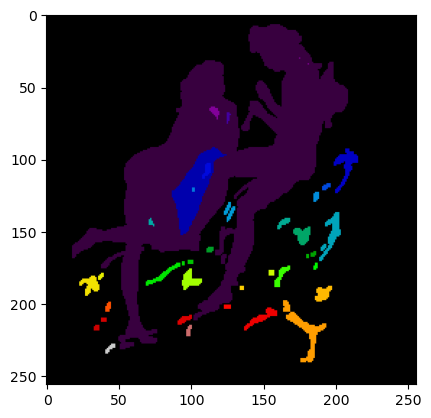

In [95]:
from skimage.measure import label

connected_components = label(neg, background=0, connectivity=2)
plt.imshow(connected_components, cmap="nipy_spectral")
plt.show()